Accuracy for svm 1.0
Accuracy for random forest 1.0
Accuracy for decision tree 1.0
[1 1 1]
[1 1 1]
[2 2 2]


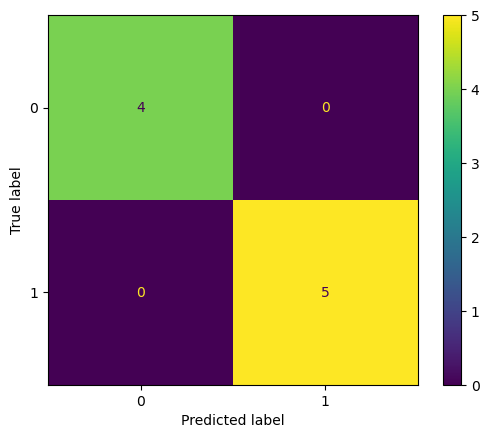

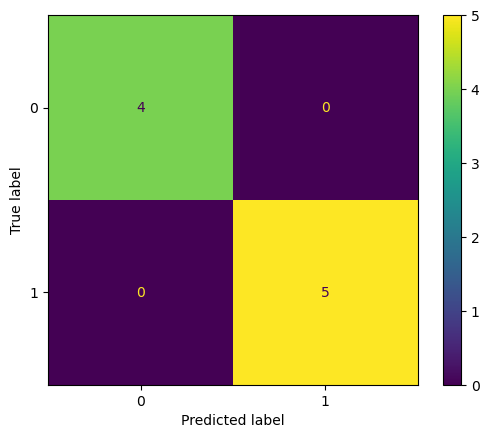

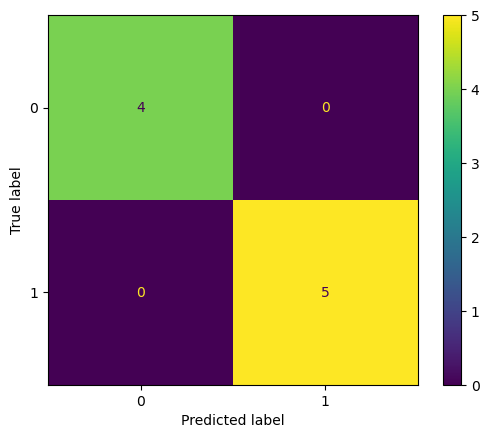

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

read=pd.read_csv(r'Resort Visit.csv')
read_1=pd.read_csv(r'predict.csv')

read.fillna(0)

training,test=train_test_split(read, test_size=0.3)
x_trg=training.drop('Resort visit',axis=1)
y_trg=training['Resort visit']
x_test=test.drop('Resort visit',axis=1)
y_test=test['Resort visit']

scaler=StandardScaler()
x_trg=scaler.fit_transform(x_trg)
x_test=scaler.transform(x_test)

#svm
svm_1=SVC()
svm_1.fit(x_trg,y_trg)
pred_1=svm_1.predict(x_test)

#Random_forest
ran=RandomForestClassifier()
ran.fit(x_trg,y_trg)
pred_2=ran.predict(x_test)

#decision_tree
tree=DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(x_trg, y_trg)
pred_3=tree.predict(x_test)


confusion_1 = confusion_matrix(y_test,pred_1)
ConfusionMatrixDisplay(confusion_1).plot()
print('Accuracy for svm '+ str(accuracy_score(y_test, pred_1)))

confusion_2 = confusion_matrix(y_test,pred_2)
ConfusionMatrixDisplay(confusion_2).plot()
print('Accuracy for random forest '+ str(accuracy_score(y_test, pred_2)))

confusion_3 = confusion_matrix(y_test,pred_3)
ConfusionMatrixDisplay(confusion_3).plot()
print('Accuracy for decision tree '+ str(accuracy_score(y_test, pred_3)))

pred_4=svm_1.predict(read_1)
pred_5=ran.predict(read_1)
pred_6=tree.predict(read_1)

print(pred_4)
print(pred_5)
print(pred_6)